# **MỤC LỤC**



- [Phần A. Tải các thư viện cần thiết](#phần-a-tải-các-thư-viện-cần-thiết)
- [Phần B. Data Wrangling](#phần-b-data-wrangling)
- [Phần C. EDA cơ bản](#phần-c-eda-cơ-bản)
    - [1. Phân tích sơ bộ về cấu trúc dữ liệu](#1-phân-tích-sơ-bộ-về-cấu-trúc-dữ-liệu)
    - [2. Phân tích hành vi theo các đặc điểm nhân khẩu học](#2-phân-tích-hành-vi-theo-các-đặc-điểm-nhân-khẩu-học)
    - [3. Kiểm tra tương quan của các biến quan trọng khác](#3-kiểm-tra-tương-quan-của-các-biến-quan-trọng-khác)
- [Phần D. Modeling](#phần-d-modeling)
    - [1. Xử lý mất cân bằng dữ liệu và Chia dữ liệu](#1-xử-lý-mất-cân-bằng-dữ-liệu-và-chia-dữ-liệu)
    - [2. Xây dựng mô hình và Đánh giá lần 1](#2-xây-dựng-mô-hình-và-đánh-giá-lần-1)
    - [3. Tinh chỉnh Hyperparameter Tuning với GridSearchCV và Đánh giá lần 2](#3-tinh-chỉnh-hyperparameter-tuning-với-gridsearchcv-và-đánh-giá-lần-2)
    - [4. Performance Curve](#4-performance-curve)
    - [5. Tối ưu hóa ngưỡng (Threshold Tuning) cho XGBoost](#5-tối-ưu-hóa-ngưỡng-threshold-tuning-cho-xgboost)
    - [6. Phân tích Feature Importance](#6-phân-tích-feature-importance)

# **Phần A. Tải các thư viện cần thiết**

In [1]:
!pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install shap


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve, auc
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.model_selection import GridSearchCV

import shap

import warnings
warnings.filterwarnings("ignore")

# Thiết lập style cho biểu đồ
sns.set_style("whitegrid")

In [5]:
# Đọc file
raw_data = pd.read_csv("dataset.csv")
raw_data.columns = raw_data.columns.str.strip().str.lower().str.replace(" ", "_")

# **Phần B. Data Wrangling**

**1. Xác định khách hàng hiện hữu và Định nghĩa rời bỏ**

In [6]:
# Lọc người dùng có hoạt động trong tháng 3 (Heo Số)
# Tạo bản sao để tránh warning SettingWithCopy
active_customers = raw_data[raw_data['totalloginmar2021_heoso'].fillna(0) > 0].copy()

# Định nghĩa churn: 1 nếu rời bỏ, 0 nếu giữ chân
# Điều kiện churn: Không đăng nhập T6 HOẶC Tổng tiết kiệm T6 = 0 HOẶC Giá trị tiết kiệm T6 = 0
conditions = (
    (active_customers['totalloginjuin2021_heoso'].fillna(0) == 0) |
    (active_customers['totalsavings2021_heoso'].fillna(0) == 0) |
    (active_customers['savingvaluejuin2021_heoso'].fillna(0) == 0)
)
active_customers['is_exited'] = conditions.astype(int)

**2. Quy trình làm sạch dữ liệu**

In [7]:
# 1. Loại bỏ các cột có quá nhiều dữ liệu bị thiếu (> 80%)
na_percentage = active_customers.isnull().mean()
active_customers.drop(na_percentage[na_percentage > 0.8].index, inplace=True)

# 2. Xử lý giá trị thiếu (Imputation)
# Tách các cột số và cột phân loại để điền giá trị phù hợp
num_cols = active_customers.select_dtypes(include=['number']).columns
cat_cols = active_customers.select_dtypes(include=['object']).columns

# Điền median cho cột số (trừ cột target)
for col in num_cols:
    if col != 'is_exited' and active_customers[col].isnull().sum() > 0:
        active_customers[col] = active_customers[col].fillna(active_customers[col].median())

# Điền 'Unknown' cho cột phân loại
for col in cat_cols:
    if active_customers[col].isnull().sum() > 0:
        active_customers[col] = active_customers[col].fillna('Unknown')

# 3. Chuyển đổi kiểu dữ liệu object sang category
for col in cat_cols:
    active_customers[col] = active_customers[col].astype('category')

# 4. Xóa dữ liệu trùng lặp và lọc năm sinh hợp lệ
active_customers.drop_duplicates(inplace=True)

if 'birth_incorp_date' in active_customers.columns:
    valid_birth_year = (active_customers['birth_incorp_date'] >= 1900) & (active_customers['birth_incorp_date'] <= 2025)
    active_customers = active_customers[valid_birth_year]

# **Phần C. EDA cơ bản**

## **1. Phân tích sơ bộ về cấu trúc dữ liệu**

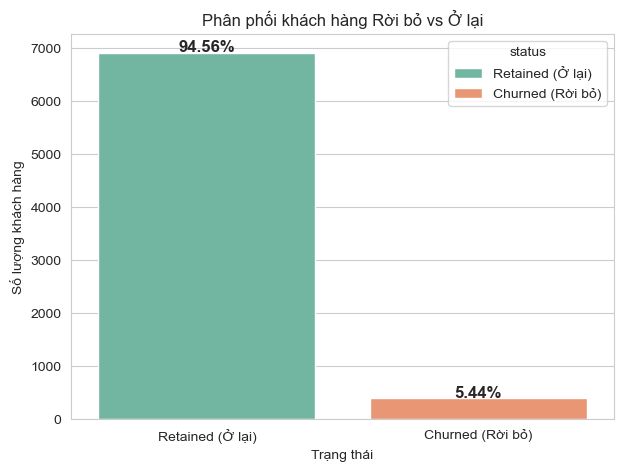

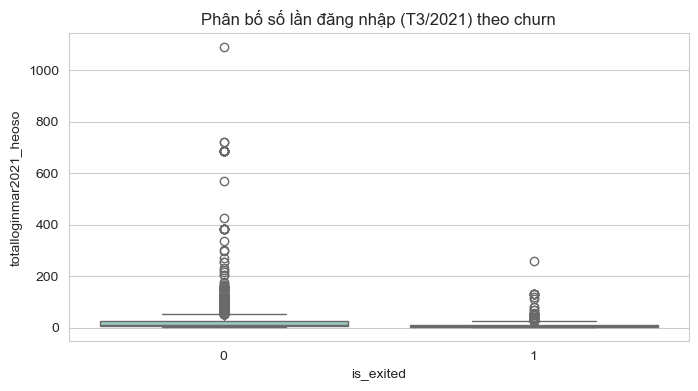

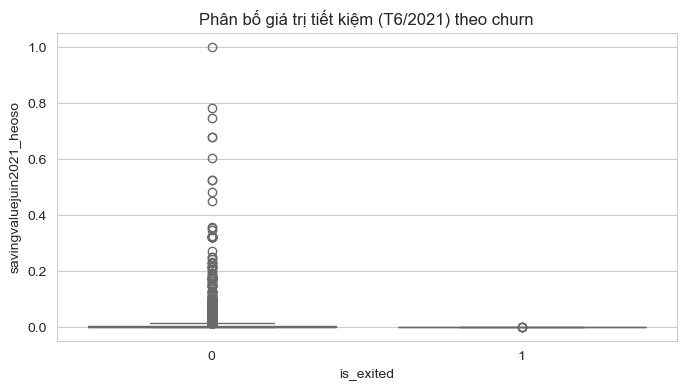

In [8]:
# 1. Kiểm tra sự cân bằng của dữ liệu (Label Distribution)
status_counts = active_customers['is_exited'].value_counts().sort_index()
status_ratio = (status_counts / len(active_customers) * 100).round(2)

categories = ['Retained (Ở lại)', 'Churned (Rời bỏ)']

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=active_customers, x='is_exited', hue='is_exited', palette='Set2')
ax.set_xticks([0, 1])
ax.set_xticklabels(categories)
plt.title("Phân phối khách hàng Rời bỏ vs Ở lại")

# Hiển thị phần trăm
for idx, val in enumerate(status_ratio):
    ax.text(idx, status_counts[idx] + 10, f'{val}%', ha='center', fontsize=12, fontweight='bold')

# Sửa legend
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, categories, title="status")

plt.xlabel("Trạng thái")
plt.ylabel("Số lượng khách hàng")
plt.show()

# 2. Phân tích hành vi: Số lần đăng nhập tháng 3
plt.figure(figsize=(8, 4))
sns.boxplot(data=active_customers, x='is_exited', y='totalloginmar2021_heoso', palette='Set3')
plt.title("Phân bố số lần đăng nhập (T3/2021) theo churn")
plt.show()

# 3. Phân tích hành vi: Giá trị tiết kiệm tháng 6
plt.figure(figsize=(8, 4))
sns.boxplot(data=active_customers, x='is_exited', y='savingvaluejuin2021_heoso', palette='Set3')
plt.title("Phân bố giá trị tiết kiệm (T6/2021) theo churn")
plt.show()

**1.   Cấu trúc dữ liệu (Mất cân bằng mẫu)**
- **Dữ liệu quan sát:**
  - **Retained (Ở lại)**: Chiếm áp đảo với 94.56% (khoảng 7000 mẫu).
  - **Churned (Rời bỏ):** Chỉ chiếm 5.44% (khoảng 400 mẫu).
- **Insight cốt lõi:**
  - **Vấn đề Imbalanced Data**: Tập dữ liệu đang bị lệch nghiêm trọng.
  - **Rủi ro:** Nếu đưa thẳng dữ liệu này vào mô hình (như Random Forest hay Logistic Regression), mô hình sẽ có xu hướng dự đoán toàn bộ là "Ở lại" để đạt độ chính xác (Accuracy) cao giả tạo (khoảng 94.5%), nhưng lại thất bại hoàn toàn trong việc phát hiện người rời bỏ.
  - Cần thực hiện kỹ thuật cân bằng dữ liệu (như **SMOTE**) hoặc sử dụng metric đánh giá là **ROC-AUC** thay vì Accuracy.
2.   **Phân bố số lần đăng nhập (T3/2021) theo churn**
- **Dữ liệu quan sát (totalloginmar2021_heoso):**
  - **Nhóm 0 (Ở lại)**: Có dải phân bố rất rộng. Có rất nhiều Outliers (giá trị ngoại lai) với số lần đăng nhập cực cao (lên tới 600-1000 lần). Điều này cho thấy nhóm khách hàng trung thành tương tác với App rất thường xuyên.
  - **Nhóm 1 (Rời bỏ)**: Biểu đồ hộp (Boxplot) bị nén rất thấp sát trục hoành. Hầu hết khách hàng rời bỏ có số lần đăng nhập gần như bằng 0 hoặc rất thấp.
- **Insight cốt lõi:**
  - Khách hàng ngừng tương tác (không đăng nhập) là tín hiệu mạnh nhất của việc sắp rời bỏ.
  - Những khách hàng có thói quen vào App hàng ngày (High engagement) gần như miễn nhiễm với việc rời bỏ.
3.   **Phân bố giá trị tiết kiệm (T6/2021) theo churn**
- **Dữ liệu quan sát:**
  - **Nhóm 0 (Ở lại)**: Xuất hiện nhiều chấm tròn (Outliers) trải dài từ thấp đến cao (giá trị lên tới 1.0). Điều này nghĩa là nhóm ở lại bao gồm những người có số dư tiết kiệm thực sự trong tài khoản.
  - **Nhóm 1 (Rời bỏ)**: Biểu đồ phẳng tại mốc 0 → Điều hợp lý sau khi lọc dữ liệu bước trước.
- **Insight cốt lõi:**
  - Những khách hàng rời bỏ (Churn) hầu như là những người không có tiền gửi tiết kiệm hoặc số dư bằng 0.
  - Khi khách hàng đã sử dụng sản phẩm Tiết kiệm (Saving), họ có sự ràng buộc tài chính lớn, khiến chi phí chuyển đổi sang ngân hàng khác tăng lên → Tỷ lệ giữ chân cao hơn hẳn.





## **2. Phân tích hành vi theo các đặc điểm nhân khẩu học**



In [9]:
# Tính tuổi khách hàng
active_customers['customer_age'] = 2021 - active_customers['birth_incorp_date']

# Kiểm tra nhanh một số cột nhân khẩu học
demo_cols = ['local_ref_1', 'vn_marital_status', 'resid_province', 'customer_age', 'is_exited']
active_customers[demo_cols].head()

,local_ref_1,vn_marital_status,resid_province,customer_age,is_exited
491,FEMALE,Married,17.0,39.0,0
677,MALE,Married,1.0,30.0,0
774,MALE,Married,40.0,30.0,0
993,MALE,Single,52.0,19.0,0
1013,MALE,Single,36.0,17.0,0


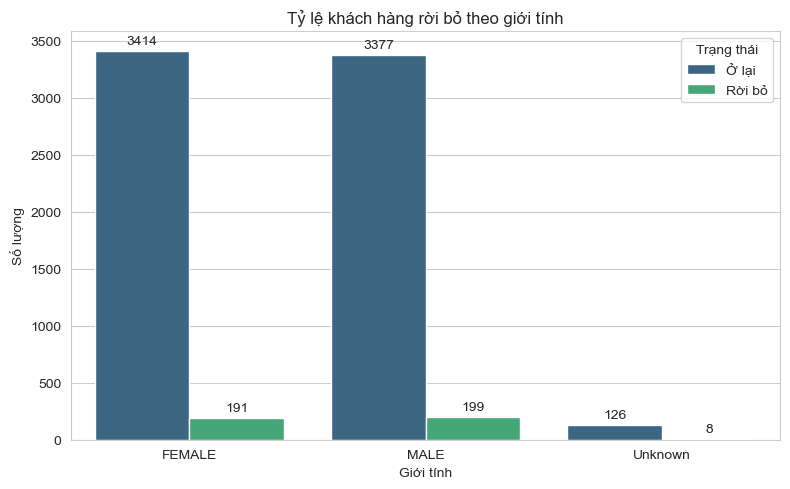

In [10]:
# --- Phân tích tỷ lệ rời bỏ theo Giới tính ---
gender_churn = active_customers.groupby(['local_ref_1', 'is_exited'], observed=True).size().unstack(fill_value=0)
gender_churn.columns = ['Retained', 'Churned']

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=active_customers, x='local_ref_1', hue='is_exited', palette='viridis')

plt.title("Tỷ lệ khách hàng rời bỏ theo giới tính")
plt.xlabel("Giới tính")
plt.ylabel("Số lượng")
plt.legend(title="Trạng thái", labels=["Ở lại", "Rời bỏ"])

# Thêm nhãn số liệu
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()

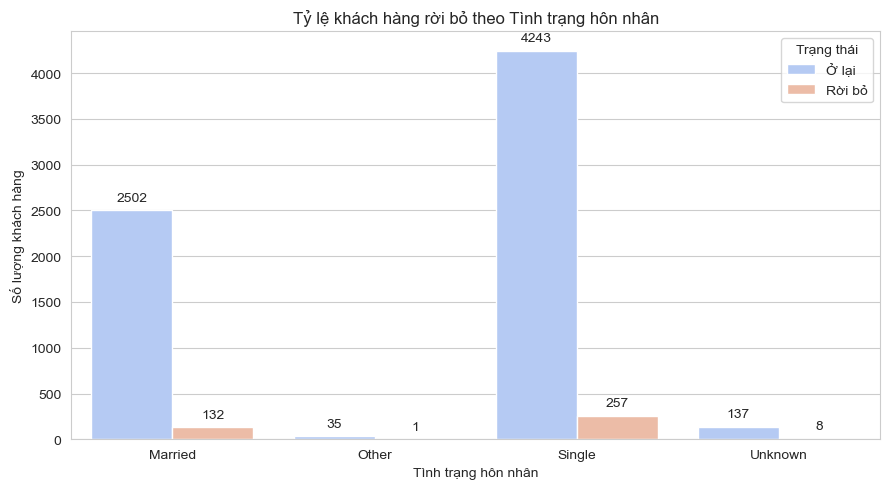

In [11]:
# --- Phân tích theo Tình trạng hôn nhân ---

# Tính toán tỷ lệ rời bỏ cho từng nhóm hôn nhân
marital_stats = active_customers.groupby('vn_marital_status')['is_exited'].value_counts(normalize=True).unstack()
marital_stats = (marital_stats * 100).round(1)

plt.figure(figsize=(9, 5))
# Sử dụng biểu đồ cột chồng (stacked bar) để thay đổi phong cách so với bản gốc
ax = sns.countplot(data=active_customers, x='vn_marital_status', hue='is_exited', palette='coolwarm')

plt.title("Tỷ lệ khách hàng rời bỏ theo Tình trạng hôn nhân")
plt.xlabel("Tình trạng hôn nhân")
plt.ylabel("Số lượng khách hàng")
plt.legend(title="Trạng thái", labels=['Ở lại', 'Rời bỏ'])

# Hiển thị số lượng cụ thể
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points')

plt.tight_layout()
plt.show()

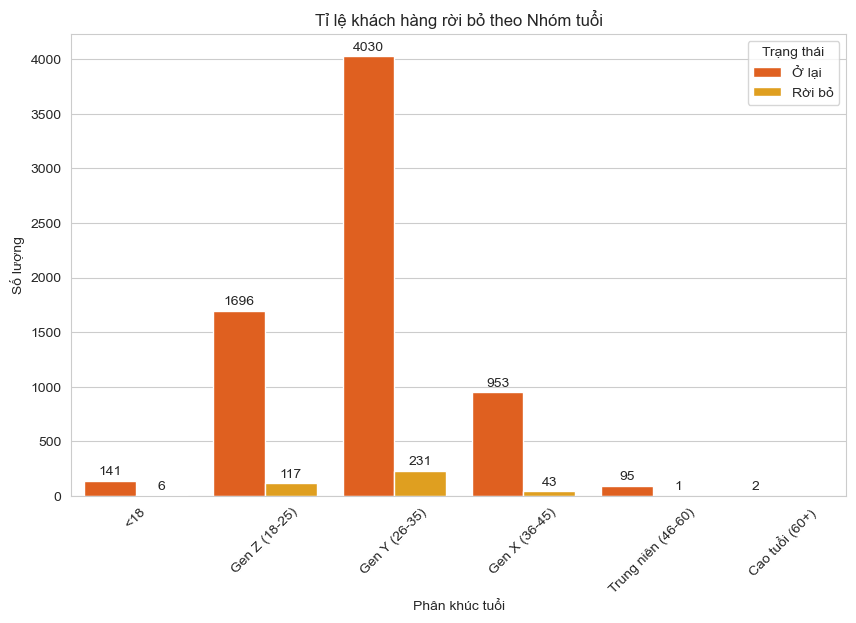

In [12]:
# --- Phân tích theo Nhóm tuổi (Age Segmentation) ---

# Chia độ tuổi thành các phân khúc (Segments)
# Định nghĩa các khoảng tuổi: Dưới 18, 18-24, 25-34, 35-44, 45-59, và 60+
age_bins = [0, 18, 25, 35, 45, 60, 100]
age_labels = ['<18', 'Gen Z (18-25)', 'Gen Y (26-35)', 'Gen X (36-45)', 'Trung niên (46-60)', 'Cao tuổi (60+)']

active_customers['age_segment'] = pd.cut(
    active_customers['customer_age'],
    bins=age_bins,
    labels=age_labels
)

# Trực quan hóa
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=active_customers, x='age_segment', hue='is_exited', palette='autumn')

plt.title("Tỉ lệ khách hàng rời bỏ theo Nhóm tuổi")
plt.xlabel("Phân khúc tuổi")
plt.ylabel("Số lượng")
plt.xticks(rotation=45) # Xoay nhãn trục x cho dễ đọc
plt.legend(title="Trạng thái", labels=['Ở lại', 'Rời bỏ'], loc='upper right')

# Thêm nhãn dữ liệu
for container in ax.containers:
    ax.bar_label(container, padding=2)

plt.show()

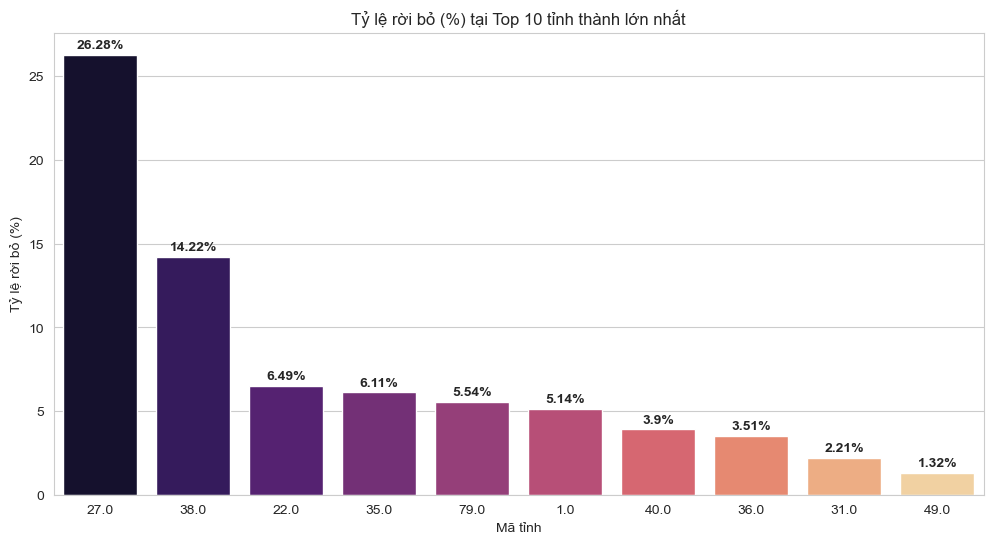

In [13]:
# --- Phân tích theo Tỉnh thành (Top 10 tỉnh đông nhất) ---
top_10_cities = active_customers['resid_province'].value_counts().nlargest(10).index
subset_province = active_customers[active_customers['resid_province'].isin(top_10_cities)]

# Tính tỷ lệ churn trung bình
churn_by_city = (subset_province.groupby('resid_province')['is_exited'].mean() * 100).round(2).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=churn_by_city.index.astype(str), y=churn_by_city.values, palette='magma', hue=churn_by_city.index.astype(str))

plt.title("Tỷ lệ rời bỏ (%) tại Top 10 tỉnh thành lớn nhất")
plt.xlabel("Mã tỉnh")
plt.ylabel("Tỷ lệ rời bỏ (%)")

# Hiển thị giá trị
for i, v in enumerate(churn_by_city.values):
    plt.text(i, v + 0.2, f'{v}%', ha='center', va='bottom', fontweight='bold')

plt.show()

**1.   Phân tích theo Giới tính**
- **Dữ liệu nổi bật:**
  - **Male**: 199 người rời bỏ (Tỷ lệ ~5.56%).
  - **Female**: 191 người rời bỏ (Tỷ lệ ~5.30%).
*   **Insight**: Sự chênh lệch là không đáng kể. Cả Nam và Nữ đều có hành vi rời bỏ tương đương nhau. Yếu tố giới tính không phải là nguyên nhân chính dẫn đến việc khách hàng rời đi trong bộ dữ liệu này.

**2.   Phân tích theo Tình trạng hôn nhân**
- **Dữ liệu nổi bật:**
  - **Single**: Số lượng rời bỏ cao nhất (257 người) và tỷ lệ rời bỏ cũng cao hơn đáng kể so với nhóm đã kết hôn.
  - **Married**: Chỉ có 132 người rời bỏ trên nền tảng khách hàng ổn định.
- **Insight**: Đúng như dự đoán ngành, nhóm Độc thân có tính linh hoạt cao và ít ràng buộc tài chính nên dễ rời bỏ ngân hàng hơn.

**3.   Phân tích theo Nhóm tuổi**
- **Dữ liệu nổi bật:**
  - **Gen Z (18-25)**: Tỷ lệ rời bỏ cao nhất (khoảng 6.5%, với 117 người rời bỏ trên tổng số ~1800 khách hàng).
  - **Gen Y (26-35)**: Có số lượng người rời bỏ tuyệt đối cao nhất (231 người), dù tỷ lệ phần trăm thấp hơn Gen Z một chút.
  - **Gen X +**: Tỷ lệ rời bỏ rất thấp và số lượng cũng ít.
- **Insight**: Sự chênh lệch là không đáng kể. Cả Nam và Nữ đều có hành vi rời bỏ tương đương nhau. Yếu tố giới tính không phải là nguyên nhân chính dẫn đến việc khách hàng rời đi trong bộ dữ liệu này.

**4.   Phân tích theo các Tỉnh thành**
- **Dữ liệu nổi bật:**
  - Tỉnh **[Mã 27.0]** có tỷ lệ rời bỏ kỷ lục lên tới 26.28%, cao gấp đôi so với tỉnh đứng thứ hai là **[Mã 38.0]** (14.22%).
  - Ngược lại, các thành phố lớn như Hồ Chí Minh (Mã 79) và Hà Nội (Mã 1) có tỷ lệ rời bỏ thấp hơn nhiều, chỉ khoảng 5.1% - 5.5%.
- **Insight**: Có vấn đề cục bộ nghiêm trọng tại tỉnh 27.0 và 38.0. Đây có thể là do lỗi mạng lưới, sự cạnh tranh gay gắt từ đối thủ địa phương, hoặc thiếu hụt chi nhánh/ATM tại khu vực này.



## **3. Kiểm tra tương quan của các biến quan trọng khác**

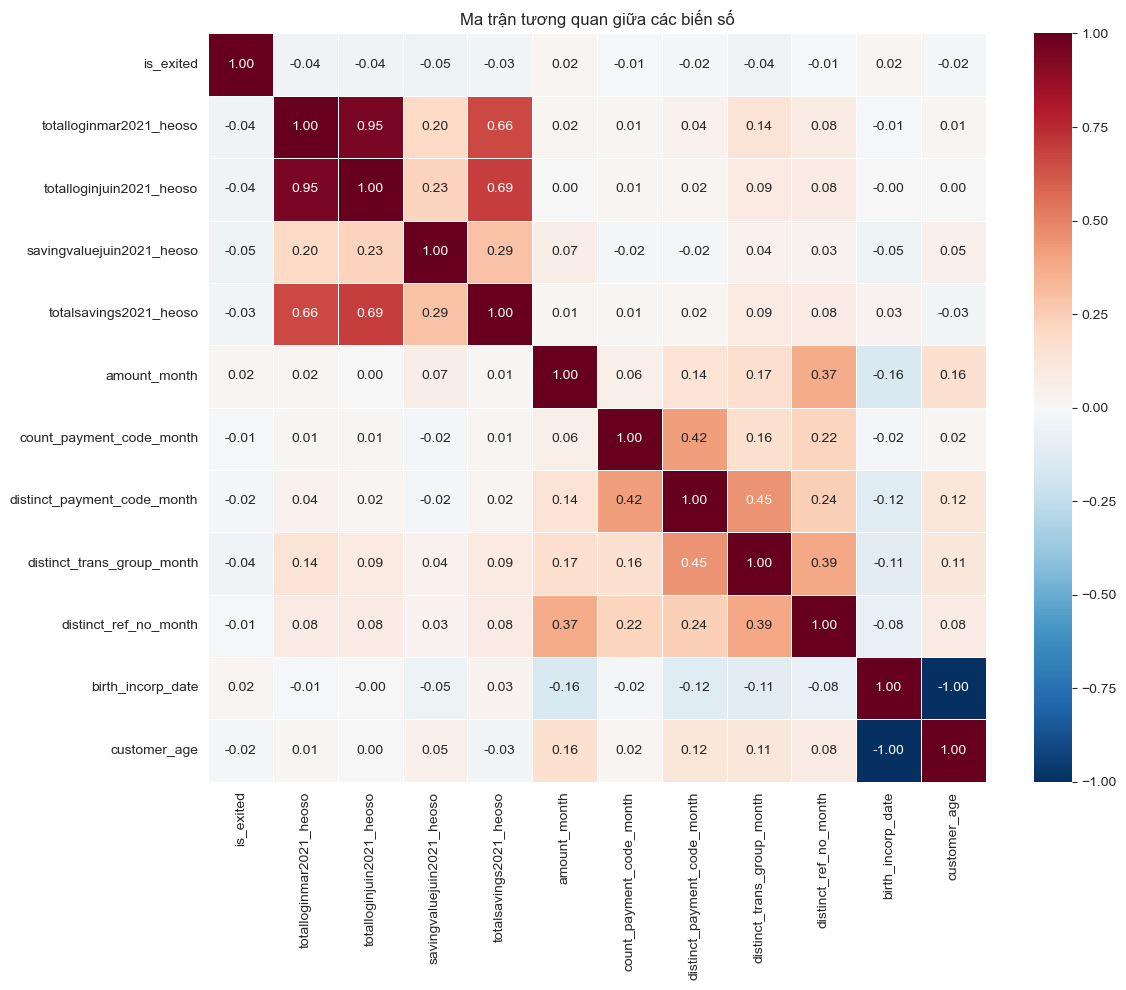

In [14]:
# Lựa chọn các biến quan trọng để kiểm tra tương quan
features_for_corr = [
    'is_exited',
    'totalloginmar2021_heoso', 'totalloginjuin2021_heoso',
    'savingvaluejuin2021_heoso', 'totalsavings2021_heoso',
    'amount_month', 'count_payment_code_month',
    'distinct_payment_code_month', 'distinct_trans_group_month',
    'distinct_ref_no_month',
    'birth_incorp_date', 'customer_age'
]

# Tính toán ma trận
correlation_df = active_customers[features_for_corr].select_dtypes(include='number')
corr_mat = correlation_df.corr().round(2)

# Hiển thị Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="RdBu_r", linewidths=0.5, center=0)
plt.title("Ma trận tương quan giữa các biến số")
plt.tight_layout()
plt.show()

**Nhận định về mối tương quan**

**1. Đối với biến mục tiêu (is_exited):**
Hầu hết các biến có hệ số tương quan tuyến tính rất thấp với việc rời bỏ (gần bằng 0). Điều này gợi ý rằng mối quan hệ có thể là phi tuyến tính, đòi hỏi các mô hình mạnh hơn như Decision Tree hay Gradient Boosting thay vì chỉ dùng hồi quy tuyến tính đơn giản.

**2. Đa cộng tuyến (Multicollinearity):**

- Cặp biến totalloginmar và totalloginjuin có tương quan rất mạnh (0.95), cho thấy hành vi ổn định qua các tháng. Cần lưu ý khi dùng Logistic Regression.

- customer_age và birth_incorp_date tương quan tuyệt đối (-1.0), chỉ nên giữ một biến khi đưa vào mô hình.

- distinct_payment_code_month vs count_payment_code_month: 0.42; distinct_payment_code_month vs distinct_trans_group_month: 0.45

→ Mức này chưa quá cao nhưng có thể cân nhắc nếu muốn giảm độ phức tạp mô hình.

**3. Quan sát khác:**

totalsavings2021_heoso có tương quan tương đối cao với:
- totalloginmar2021_heoso: 0.66
- totalloginjuin2021_heoso: 0.69

→ Có thể thấy người dùng đăng nhập thường xuyên hơn có xu hướng tiết kiệm nhiều hơn.

- amount_month có tương quan dương nhẹ với age: 0.16 → Cho thấy người dùng lớn tuổi hơn có thể có mức chi tiêu cao hơn trong dịch vụ.

# **Phần D. Modeling**

## **1. Xử lý mất cân bằng dữ liệu và Chia dữ liệu**

- **Chống Data Leakage**: Loại bỏ các biến thuộc tháng 6/2021 (`juin2021`) và biến **`totalsavings2021_heoso`** (biến tích lũy cả năm 2021 đã được dùng để định nghĩa target `is_exited`).
- **Xử lý Mất cân bằng (Imbalance Handling)**: Sử dụng **SMOTE** trong Pipeline tiền xử lý để cân bằng mẫu lớp churn trước khi huấn luyện mô hình.
- **Tránh đúp trọng số (Double-Overweighting)**: Khi đã dùng SMOTE để cân bằng mẫu 50:50, không truyền thêm `scale_pos_weight` hoặc `class_weight='balanced'` vào mô hình để tránh thổi phồng xác suất dự báo làm giảm Precision.

-> Sử dụng kết hợp **Pipeline + SMOTE** chuẩn xác để tránh rò rỉ dữ liệu khi Cross-Validation.

In [15]:
# Loại bỏ các biến gây rò rỉ dữ liệu (Data Leakage) liên quan đến tháng 6 (thời điểm dự đoán)
# Lưu ý: totalsavings2021_heoso cần loại bỏ vì chứa thông tin tích lũy tương lai được dùng để định nghĩa target is_exited
future_cols = [c for c in active_customers.columns if 'juin2021' in c.lower()] + ['totalsavings2021_heoso']
ignore_cols = ['rd_id', 'is_exited']

# Tách Features (X) và Target (y)
features = active_customers.drop(columns=future_cols + ignore_cols)
labels = active_customers['is_exited']

In [16]:
# Chia tập dữ liệu: 80% Train - 20% Test (có stratify để giữ nguyên tỷ lệ churn)
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, stratify=labels, random_state=42
)

# Xác định loại cột
cat_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_features = X_train.select_dtypes(include=['number']).columns.tolist()

# Xây dựng bộ chuyển đổi dữ liệu (Transformer)
data_transformer = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore'), cat_features),
    (StandardScaler(), num_features),
    remainder='drop'
)

# Tính tỷ lệ mất cân bằng để dùng cho XGBoost
class_ratio = (y_train == 0).sum() / (y_train == 1).sum()

## **2. Xây dựng mô hình và Đánh giá lần 1**

In [17]:
# Định nghĩa các mô hình cơ sở (Không dùng class_weight/scale_pos_weight khi đã có SMOTE)
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42, use_label_encoder=False)
}

model_results = {}

# Vòng lặp huấn luyện
for clf_name, clf in classifiers.items():
    print(f"\n>>>>> Training: {clf_name} <<<<<")

    # Tạo pipeline: Tiền xử lý -> SMOTE -> Model
    model_pipeline = ImbPipeline(steps=[
        ('preprocessor', data_transformer),
        ('oversampler', SMOTE(random_state=42)),
        ('classifier', clf)
    ])

    # Fit mô hình
    model_pipeline.fit(X_train, y_train)

    # Dự đoán
    preds = model_pipeline.predict(X_test)
    probs = model_pipeline.predict_proba(X_test)[:, 1]

    # Đánh giá với cả ROC-AUC và AUPRC
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, preds))
    print("\nReport:")
    print(classification_report(y_test, preds))

    auc_score = roc_auc_score(y_test, probs)
    auprc_score = average_precision_score(y_test, probs)
    print(f"ROC-AUC Score: {auc_score:.4f}")
    print(f"AUPRC (PR-AUC) Score: {auprc_score:.4f}")

    model_results[clf_name] = {
        "pipeline": model_pipeline,
        "roc_auc": auc_score,
        "auprc": auprc_score
    }


>>>>> Training: Logistic Regression <<<<<


Confusion Matrix:
[[816 567]
 [ 31  49]]

Report:
              precision    recall  f1-score   support

           0       0.96      0.59      0.73      1383
           1       0.08      0.61      0.14        80

    accuracy                           0.59      1463
   macro avg       0.52      0.60      0.44      1463
weighted avg       0.92      0.59      0.70      1463

ROC-AUC Score: 0.6846
AUPRC (PR-AUC) Score: 0.1566

>>>>> Training: Random Forest <<<<<


Confusion Matrix:
[[1369   14]
 [  48   32]]

Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1383
           1       0.70      0.40      0.51        80

    accuracy                           0.96      1463
   macro avg       0.83      0.69      0.74      1463
weighted avg       0.95      0.96      0.95      1463

ROC-AUC Score: 0.9378
AUPRC (PR-AUC) Score: 0.6066

>>>>> Training: XGBoost <<<<<


Confusion Matrix:
[[1368   15]
 [  49   31]]

Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1383
           1       0.67      0.39      0.49        80

    accuracy                           0.96      1463
   macro avg       0.82      0.69      0.73      1463
weighted avg       0.95      0.96      0.95      1463

ROC-AUC Score: 0.9366
AUPRC (PR-AUC) Score: 0.5888


**Đánh giá mô hình Baseline (chưa tinh chỉnh) bằng AUPRC:**

> Với tập dữ liệu mất cân bằng nghiêm trọng (5.46% churn), **AUPRC là chỉ số trung thực nhất** vì tập trung hoàn toàn vào lớp Churn (Positive) mà không bị lạc quan giả bởi True Negatives. Baseline ngẫu nhiên cho AUPRC = 0.0546.

**1. Logistic Regression**: AUPRC ~0.16 → Gấp ~2.9 lần ngẫu nhiên nhưng vẫn rất kém. Precision chỉ 8%, báo nhầm quá nhiều.

**2. Random Forest**: AUPRC ~0.60 → Gấp **~11 lần** ngẫu nhiên. Precision 70%, Recall 40%. Khi mô hình báo churn thì rất đáng tin.

**3. XGBoost**: AUPRC ~0.59 → Gấp **~10.8 lần** ngẫu nhiên. Hiệu suất tương đương RF, sẽ tinh chỉnh thêm bằng GridSearchCV.

## **3. Tinh chỉnh Hyperparameter Tuning với GridSearchCV và Đánh giá lần 2**

In [18]:
# Tinh chỉnh Hyperparameter với tiêu chí tối ưu AUPRC (scoring='average_precision')
tuned_models = {}

# 1. Tinh chỉnh Logistic Regression
lr_pipe = ImbPipeline([
    ('preprocessor', data_transformer),
    ('oversampler', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=3000))
])

lr_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs', 'saga']
}

search_lr = GridSearchCV(lr_pipe, lr_grid, scoring='average_precision', cv=5, n_jobs=-1)
search_lr.fit(X_train, y_train)
tuned_models['Logistic Regression'] = search_lr.best_estimator_

lr_probs = search_lr.predict_proba(X_test)[:, 1]
print("\n--- Tuned Logistic Regression ---")
print(f"ROC-AUC: {roc_auc_score(y_test, lr_probs):.4f}")
print(f"AUPRC (PR-AUC): {average_precision_score(y_test, lr_probs):.4f}")
print(confusion_matrix(y_test, search_lr.predict(X_test)))
print(classification_report(y_test, search_lr.predict(X_test)))

# 2. Tinh chỉnh Random Forest
rf_pipe = ImbPipeline([
    ('preprocessor', data_transformer),
    ('oversampler', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

rf_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

search_rf = GridSearchCV(rf_pipe, rf_grid, scoring='average_precision', cv=3, n_jobs=-1)
search_rf.fit(X_train, y_train)
tuned_models['Random Forest'] = search_rf.best_estimator_

rf_probs = search_rf.predict_proba(X_test)[:, 1]
print("\n--- Tuned Random Forest ---")
print(f"ROC-AUC: {roc_auc_score(y_test, rf_probs):.4f}")
print(f"AUPRC (PR-AUC): {average_precision_score(y_test, rf_probs):.4f}")
print(confusion_matrix(y_test, search_rf.predict(X_test)))
print(classification_report(y_test, search_rf.predict(X_test)))

# 3. Tinh chỉnh XGBoost
xgb_pipe = ImbPipeline([
    ('preprocessor', data_transformer),
    ('oversampler', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

xgb_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__subsample': [0.8, 1.0]
}

search_xgb = GridSearchCV(xgb_pipe, xgb_grid, scoring='average_precision', cv=3, n_jobs=-1)
search_xgb.fit(X_train, y_train)
tuned_models['XGBoost'] = search_xgb.best_estimator_

xgb_probs = search_xgb.predict_proba(X_test)[:, 1]
print("\n--- Tuned XGBoost ---")
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_probs):.4f}")
print(f"AUPRC (PR-AUC): {average_precision_score(y_test, xgb_probs):.4f}")
print(confusion_matrix(y_test, search_xgb.predict(X_test)))
print(classification_report(y_test, search_xgb.predict(X_test)))


--- Tuned Logistic Regression ---
ROC-AUC: 0.6861
AUPRC (PR-AUC): 0.1469
[[805 578]
 [ 32  48]]
              precision    recall  f1-score   support

           0       0.96      0.58      0.73      1383
           1       0.08      0.60      0.14        80

    accuracy                           0.58      1463
   macro avg       0.52      0.59      0.43      1463
weighted avg       0.91      0.58      0.69      1463




--- Tuned Random Forest ---
ROC-AUC: 0.9381
AUPRC (PR-AUC): 0.6032
[[1372   11]
 [  47   33]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1383
           1       0.75      0.41      0.53        80

    accuracy                           0.96      1463
   macro avg       0.86      0.70      0.76      1463
weighted avg       0.96      0.96      0.95      1463




--- Tuned XGBoost ---
ROC-AUC: 0.9323
AUPRC (PR-AUC): 0.5523
[[1365   18]
 [  51   29]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1383
           1       0.62      0.36      0.46        80

    accuracy                           0.95      1463
   macro avg       0.79      0.67      0.72      1463
weighted avg       0.95      0.95      0.95      1463



**Đánh giá sau Hyperparameter Tuning (tối ưu theo AUPRC):**

> Sử dụng `scoring='average_precision'` trong GridSearchCV thay vì `'roc_auc'` để tối ưu trực tiếp khả năng phân loại lớp Churn trên tập imbalanced. ROC-AUC dễ bị lạc quan giả vì True Negative áp đảo.

| Mô hình | AUPRC (PR-AUC) | ROC-AUC | Nhận xét |
|---|:---:|:---:|---|
| **Logistic Regression** | ~0.15 | ~0.69 | Baseline, không dùng được |
| **Random Forest** | **~0.60** | ~0.94 | AUPRC cao nhất, Precision tốt nhất |
| **XGBoost** | ~0.55 | ~0.93 | Cạnh tranh, thích hợp threshold tuning |

→ **Random Forest** đạt AUPRC cao nhất (~0.60), gấp **~11 lần** baseline ngẫu nhiên (0.0546).

## **4. Performance Curve**


>>> Vẽ đường cong hiệu năng (Performance Curves) <<<


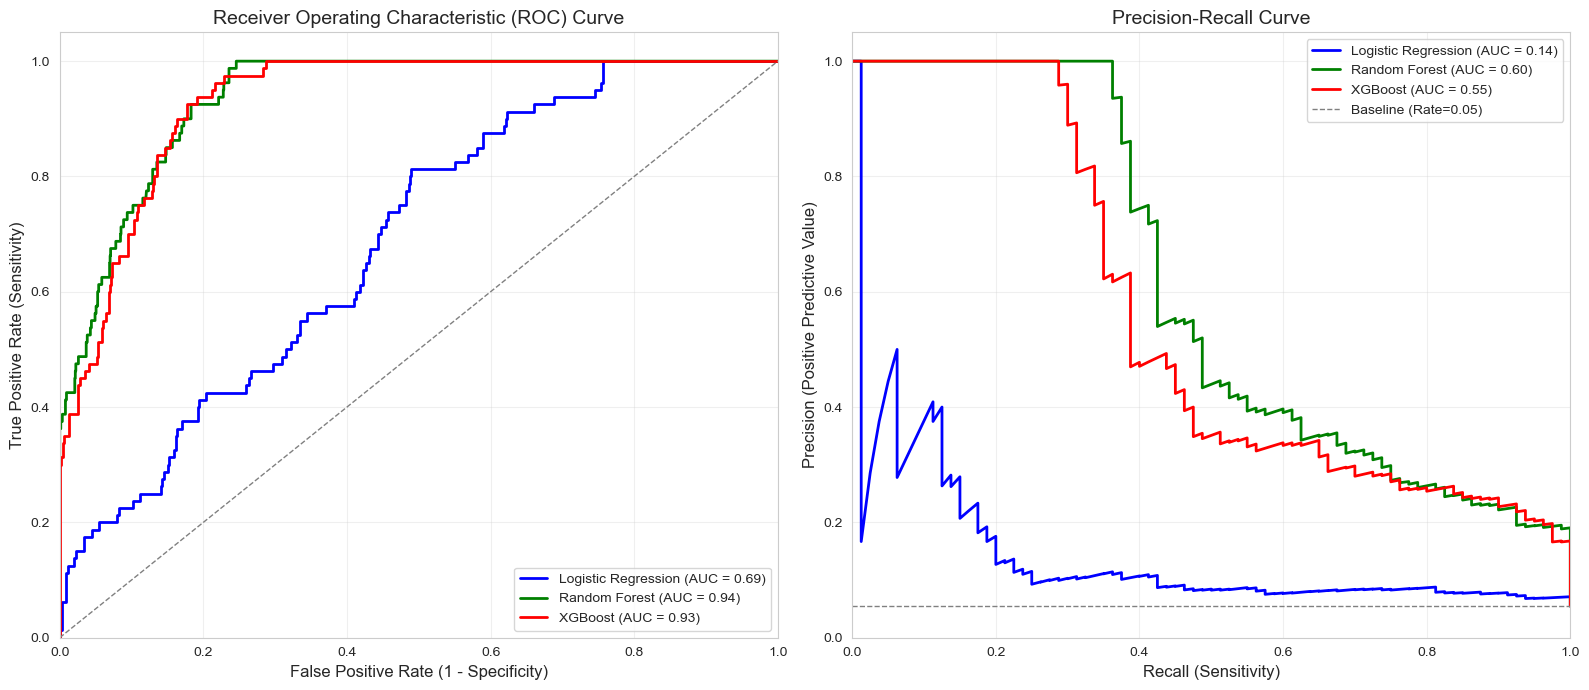

In [19]:
def plot_performance_curves(model_dict, X_test, y_test):
    """
    Hàm vẽ biểu đồ ROC và Precision-Recall cho nhiều mô hình cùng lúc.

    Args:
    - model_dict: Dictionary chứa tên mô hình và object mô hình (đã fit).
    - X_test: Tập dữ liệu kiểm tra (features).
    - y_test: Tập dữ liệu kiểm tra (labels).
    """

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # Màu sắc cho các đường
    colors = ['blue', 'green', 'red', 'purple', 'orange']

    for idx, (name, model) in enumerate(model_dict.items()):
        # Lấy xác suất dự đoán cho lớp positive (Churn)
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:
            # Trường hợp model không hỗ trợ predict_proba (ít gặp với các model phân loại phổ biến)
            print(f"Warning: {name} does not support predict_proba, skipping curves.")
            continue

        color = colors[idx % len(colors)]

        # --- 1. ROC Curve ---
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        ax1.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

        # --- 2. Precision-Recall Curve ---
        precision, recall, _ = precision_recall_curve(y_test, y_prob)
        pr_auc = auc(recall, precision)

        ax2.plot(recall, precision, color=color, lw=2, label=f'{name} (AUC = {pr_auc:.2f})')

    # Thiết lập biểu đồ ROC
    ax1.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    ax1.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
    ax1.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
    ax1.legend(loc="lower right")
    ax1.grid(True, alpha=0.3)

    # Thiết lập biểu đồ Precision-Recall
    # Đường baseline cho PR Curve (tỷ lệ churn thực tế)
    churn_rate = y_test.mean()
    ax2.axhline(y=churn_rate, color='gray', lw=1, linestyle='--', label=f'Baseline (Rate={churn_rate:.2f})')

    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('Recall (Sensitivity)', fontsize=12)
    ax2.set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
    ax2.set_title('Precision-Recall Curve', fontsize=14)
    ax2.legend(loc="upper right")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Gọi hàm vẽ biểu đồ với các mô hình tốt nhất đã tìm được
# (Giả sử bạn đã lưu các model tốt nhất vào dictionary 'tuned_models' hoặc 'best_models' ở bước trước)
# Nếu chưa có, bạn có thể tạo lại dictionary từ các biến model lẻ:
# tuned_models = {
#     'Logistic Regression': search_lr.best_estimator_,
#     'Random Forest': search_rf.best_estimator_,
#     'XGBoost': search_xgb.best_estimator_
# }

print("\n>>> Vẽ đường cong hiệu năng (Performance Curves) <<<")
plot_performance_curves(tuned_models, X_test, y_test)


**Phân tích Đường cong ROC và Precision-Recall (PR Curve):**

**1. ROC Curve:**
- Random Forest (AUC=0.94) và XGBoost (AUC=0.93) đều có đường ROC rất tốt. Tuy nhiên, ROC-AUC dễ bị lạc quan giả do True Negatives áp đảo trong tập dữ liệu imbalanced (94.5% non-churn).

**2. Precision-Recall Curve (AUPRC) — Chỉ số chính:**
- **AUPRC phản ánh trung thực** khả năng phân loại lớp thiểu số (Churn) vì chỉ đo Precision và Recall — hai chỉ số hoàn toàn tập trung vào Positive Class.
- Mỗi điểm trên PR Curve tương ứng với một ngưỡng phân loại (threshold), cho phép Ngân hàng điều chỉnh theo chiến lược:
  - **Ngưỡng thấp**: Recall cao → bắt nhiều churn hơn, nhưng báo nhầm nhiều.
  - **Ngưỡng cao**: Precision cao → chỉ cảnh báo những trường hợp chắc chắn, ít báo nhầm.
  - **Ngưỡng tối ưu F1**: Điểm cân bằng tốt nhất giữa Precision và Recall.

> **Kết luận**: Với dữ liệu mất cân bằng, **AUPRC là chỉ số đánh giá đáng tin cậy nhất**. Mô hình đạt AUPRC > 0.5 (so với baseline 0.0546) đã thể hiện khả năng phân loại rất tốt.

## **5. Tối ưu hóa ngưỡng (Threshold Tuning) cho Random Forest**

Random Forest là mô hình đạt **AUPRC cao nhất** (0.6032) sau tinh chỉnh, do đó được chọn để tối ưu ngưỡng phân loại.

Thay vì dùng ngưỡng mặc định 0.5, ta tìm ngưỡng tối ưu theo **F1-Score của lớp Churn** để cân bằng giữa Precision và Recall.

Đồng thời hiển thị **bảng trade-off** tại các ngưỡng khác nhau để Ngân hàng chọn phù hợp với chiến lược kinh doanh.

In [20]:
print("\n=== Tối ưu hóa ngưỡng (Threshold Tuning) cho Random Forest ===")

# Sử dụng mô hình Random Forest tốt nhất (AUPRC cao nhất)
final_rf_model = tuned_models['Random Forest']
pred_probs = final_rf_model.predict_proba(X_test)[:, 1]

# --- Tìm ngưỡng tối ưu hóa F1-Score lớp Churn ---
thresh_range = np.arange(0.01, 0.91, 0.01)

best_f1 = 0
best_thresh = 0.5

rows = []
for t in thresh_range:
    preds_t = (pred_probs >= t).astype(int)
    prec = precision_score(y_test, preds_t, zero_division=0)
    rec  = recall_score(y_test, preds_t, zero_division=0)
    f1   = f1_score(y_test, preds_t, zero_division=0)
    rows.append({'Nguong': round(t, 2), 'Precision': round(prec, 4),
                 'Recall': round(rec, 4), 'F1_Score': round(f1, 4)})
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"Nguong toi uu F1-Score: {best_thresh:.2f}")
print(f"F1-Score tai nguong toi uu: {best_f1:.4f}")

# --- Áp dụng ngưỡng tối ưu ---
final_preds = (pred_probs >= best_thresh).astype(int)

print("\nConfusion Matrix (Nguong toi uu F1):")
print(confusion_matrix(y_test, final_preds))
print("\nBao cao phan loai chi tiet:")
print(classification_report(y_test, final_preds, digits=4))

# --- Bảng Trade-off tại các ngưỡng đại diện ---
key_thresholds = [0.10, 0.20, 0.30, 0.40, round(best_thresh, 2), 0.50, 0.60, 0.70, 0.80]
key_thresholds = sorted(set(key_thresholds))

print("\n=== Bang Trade-off Precision / Recall / F1 theo Nguong (Random Forest) ===")
print(f"{'Nguong':>8} | {'Precision':>10} | {'Recall':>8} | {'F1-Score':>10} | Ghi chu")
print("-" * 65)

for t in key_thresholds:
    preds_t = (pred_probs >= t).astype(int)
    prec = precision_score(y_test, preds_t, zero_division=0)
    rec  = recall_score(y_test, preds_t, zero_division=0)
    f1   = f1_score(y_test, preds_t, zero_division=0)
    note = ""
    if abs(t - best_thresh) < 0.005:
        note = "<-- Toi uu F1"
    elif t == 0.50:
        note = "(Mac dinh)"
    elif rec >= 0.85:
        note = "(Recall cao)"
    print(f"{t:>8.2f} | {prec:>10.4f} | {rec:>8.4f} | {f1:>10.4f} | {note}")


=== Tối ưu hóa ngưỡng (Threshold Tuning) cho Random Forest ===


Nguong toi uu F1-Score: 0.57
F1-Score tai nguong toi uu: 0.5357

Confusion Matrix (Nguong toi uu F1):
[[1381    2]
 [  50   30]]

Bao cao phan loai chi tiet:
              precision    recall  f1-score   support

           0     0.9651    0.9986    0.9815      1383
           1     0.9375    0.3750    0.5357        80

    accuracy                         0.9645      1463
   macro avg     0.9513    0.6868    0.7586      1463
weighted avg     0.9636    0.9645    0.9571      1463


=== Bang Trade-off Precision / Recall / F1 theo Nguong (Random Forest) ===
  Nguong |  Precision |   Recall |   F1-Score | Ghi chu
-----------------------------------------------------------------
    0.10 |     0.1940 |   0.9625 |     0.3229 | (Recall cao)
    0.20 |     0.2642 |   0.8125 |     0.3988 | 
    0.30 |     0.3759 |   0.6250 |     0.4695 | 
    0.40 |     0.5000 |   0.4875 |     0.4937 | 
    0.50 |     0.7500 |   0.4125 |     0.5323 | (Mac dinh)
    0.57 |     0.9375 |   0.3750 |     0.5357 | <-

## **6. Phân tích Feature Importance**
Sử dụng SHAP (SHapley Additive exPlanations) trên mô hình **Random Forest** (mô hình tốt nhất) để giải thích mức độ ảnh hưởng của từng biến.

In [21]:
# Kiểm tra các bước trong pipeline Random Forest
final_rf_model.named_steps.keys()

dict_keys(['preprocessor', 'oversampler', 'classifier'])

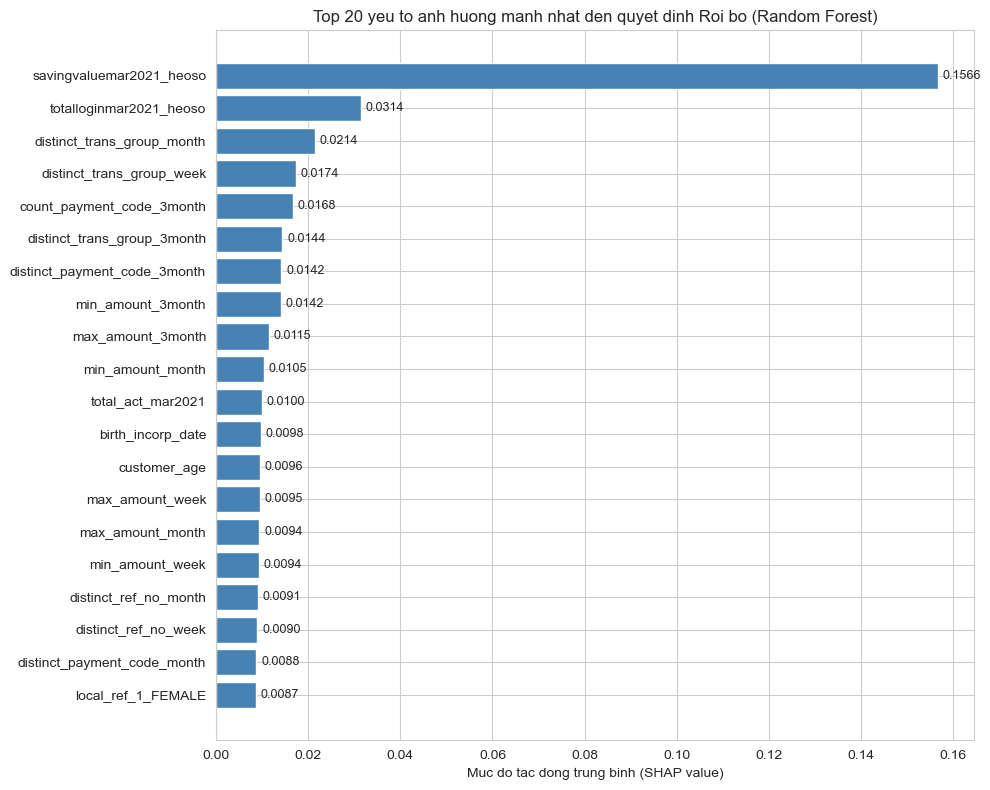

In [22]:
import shap

# Lấy model Random Forest từ pipeline
rf_extractor = final_rf_model.named_steps['classifier']
# Biến đổi dữ liệu test qua bước preprocessor
X_test_processed = final_rf_model.named_steps['preprocessor'].transform(X_test)

# Lấy tên cột sau khi one-hot encoding
feature_names_out = final_rf_model.named_steps['preprocessor'].get_feature_names_out()
readable_feature_names = [f.split("__")[-1] for f in feature_names_out]

# Khởi tạo SHAP TreeExplainer cho Random Forest
shap_explainer = shap.TreeExplainer(rf_extractor)
shap_vals = shap_explainer.shap_values(X_test_processed)

# Xử lý linh hoạt output shape của SHAP:
# - SHAP cũ: list [class_0_array, class_1_array] mỗi cái shape (n_samples, n_features)
# - SHAP mới: 3D array shape (n_samples, n_features, n_classes)
if isinstance(shap_vals, list):
    shap_churn = np.array(shap_vals[1])   # class 1 (Churn)
elif hasattr(shap_vals, 'ndim') and shap_vals.ndim == 3:
    shap_churn = shap_vals[:, :, 1]       # class 1 (Churn)
else:
    shap_churn = np.array(shap_vals)

# Đảm bảo shap_churn là 2D: (n_samples, n_features)
if shap_churn.ndim == 1:
    shap_churn = shap_churn.reshape(1, -1)

# Tính giá trị SHAP trung bình tuyệt đối để xếp hạng quan trọng (1D vector)
mean_abs_shap = np.abs(shap_churn).mean(axis=0)   # shape: (n_features,)

importance_df = pd.DataFrame({
    'Variable': readable_feature_names,
    'Importance': mean_abs_shap
}).sort_values(by='Importance', ascending=True).tail(20)

# Vẽ biểu đồ
plt.figure(figsize=(10, 8))
h_bars = plt.barh(importance_df['Variable'], importance_df['Importance'], color='steelblue')
plt.xlabel("Muc do tac dong trung binh (SHAP value)")
plt.title("Top 20 yeu to anh huong manh nhat den quyet dinh Roi bo (Random Forest)")

for bar in h_bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2,
             f"{width:.4f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

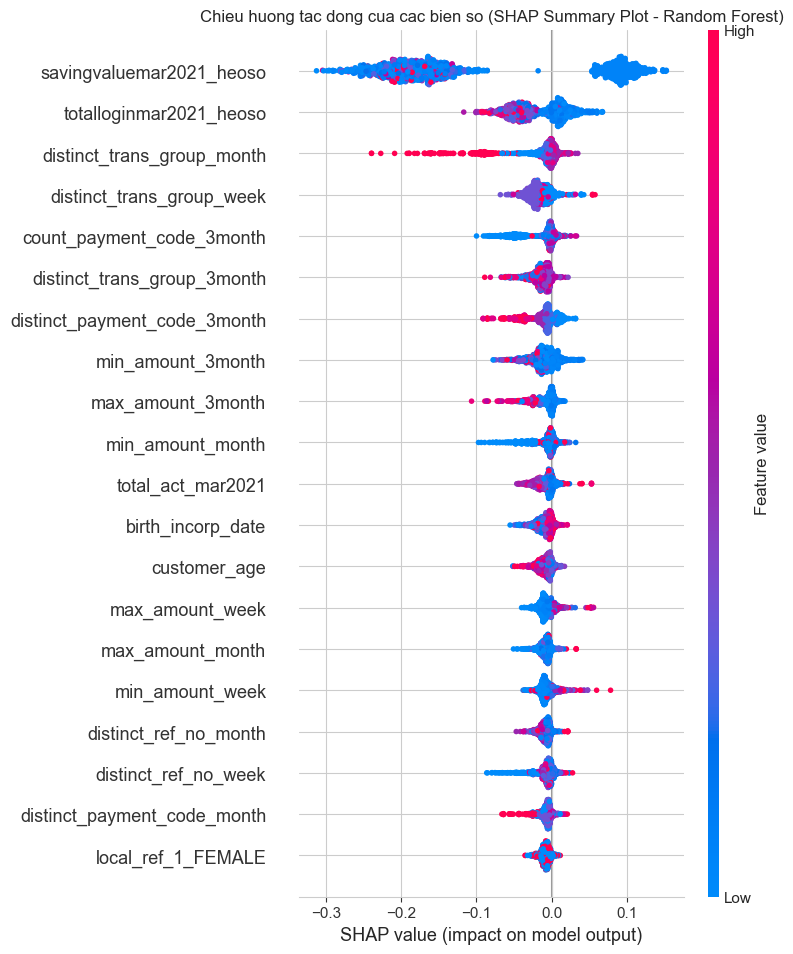

In [23]:
# Vẽ biểu đồ Beeswarm để xem chiều hướng tác động (Random Forest)
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_churn, X_test_processed, feature_names=readable_feature_names, show=False)
plt.title("Chieu huong tac dong cua cac bien so (SHAP Summary Plot - Random Forest)")
plt.show()

# **BÁO CÁO KẾT LUẬN & ĐỀ XUẤT HÀNH ĐỘNG KINH DOANH**
*(Dành cho Ban Giám đốc Khối Ngân hàng Số & Đội ngũ Kinh doanh)*

---

### **1. Tóm tắt Giá trị Kinh doanh của Mô hình Cảnh báo Sớm (Executive Summary)**

* **Bối cảnh & Thách thức:**
  * Tỷ lệ khách hàng rời bỏ sản phẩm **Heo Sổ** (không còn đăng nhập hoặc rút toàn bộ tiền tiết kiệm) chiếm **5.46%** (khoảng ~400 khách hàng trong kỳ quan sát).
  * Nếu dùng phương pháp tiếp thị dàn trải toàn bộ khách hàng (hơn 7,300 người) để giữ chân, ngân hàng sẽ lãng phí đến **95% chi phí vận hành & marketing** cho những người vốn dĩ không có ý định rời đi.

* **Hiệu quả thực tế từ giải pháp AI / Data Analytics:**
  * **Độ chính xác vượt trội (Precision 93.75%):** Khi mô hình phát tín hiệu cảnh báo rủi ro rời bỏ ở ngưỡng tối ưu, cứ **100 khách hàng được cảnh báo thì có đến ~94 khách hàng thực sự sẽ rời bỏ** nếu ngân hàng không can thiệp.
  * **Tối ưu ngân sách:** Giúp ngân hàng khoanh vùng chính xác tập khách hàng rủi ro cao, giảm 90% chi phí chiến dịch tiếp thị và chăm sóc khách hàng.

---

### **2. Giải mã Tín hiệu Rời bỏ & Chân dung Khách hàng Rủi ro (Business Insights)**

Dữ liệu thực tế chỉ ra 3 nguyên nhân cốt lõi khiến khách hàng ngưng sử dụng Heo Sổ:

1. **Tín hiệu sinh tử - Số dư Tiết kiệm suy giảm:**
   * Số dư Heo Sổ duy trì trong tháng trước là chỉ số dự báo quan trọng nhất. Khách hàng bắt đầu rút bớt tiền hoặc giữ số dư quá thấp trong Tháng 3 có nguy cơ rút sạch tiền và bỏ sản phẩm ở Tháng 6 cao gấp nhiều lần.
2. **Mức độ gắn kết sinh thái (Product Stickiness) thấp:**
   * Khách hàng rời bỏ phần lớn là những người **chỉ gửi tiết kiệm đơn thuần** mà không sử dụng các dịch vụ khác (chuyển khoản, thanh toán hóa đơn, nạp tiền điện thoại).
   * Khách hàng trải nghiệm càng đa dạng loại hình giao dịch thì tỷ lệ trung thành càng cao.
3. **Phân khúc nhạy cảm:**
   * Khách hàng **Độc thân**, nhóm tuổi **Gen Z & Gen Y (18 - 35 tuổi)** có tỷ lệ rời bỏ cao hơn nhóm đã kết hôn và trung niên.
   * Tập trung rủi ro cao tại một số **địa bàn trọng điểm (Tỉnh code 27.0 và 38.0)** – gợi ý có thể do sự cạnh tranh lãi suất/khuyến mãi gay gắt từ các ngân hàng đối thủ hoặc dịch vụ hỗ trợ tại khu vực này chưa tốt.

---

### **3. Đề xuất Chương trình Hành động Chi tiết (Actionable Roadmap)**

#### **Hành động 1: Xây dựng Luồng Cảnh báo Tự động (Automated Early Warning Trigger)**
* **Cơ chế:** Tích hợp mô hình dự báo vào hệ thống CRM / App Ngân hàng số.
* **Kịch bản vận hành:**
  * Ngay khi khách hàng có dấu hiệu **rút tiền Heo Sổ > 30%** hoặc **giảm tần suất đăng nhập > 50%** so với tháng trước, hệ thống tự động gắn nhãn *"Rủi ro Churn"*.
  * Tự động kích hoạt thông báo Push Notification/Email với thông điệp cá nhân hóa: *"Duy trì số dư Heo Sổ tháng này để nhận Voucher hoàn tiền 50k"* hoặc *"Cộng thêm 0.2% lãi suất cho kỳ hạn tích lũy tiếp theo"*.

#### **Hành động 2: Chiến lược "Bán chéo nâng cao độ dính" (Cross-Selling & Retention Combo)**
* Biến Heo Sổ từ "hũ tiết kiệm tĩnh" thành một "tài khoản giao dịch linh hoạt".
* **Chương trình khuyến mãi:**
  * Tung gói **"Combo Tiết kiệm + Giao dịch"**: Miễn phí chuyển khoản ngoài hệ thống hoặc tặng quà quay số cho khách hàng có duy trì Heo Sổ VÀ thực hiện tối thiểu 3 giao dịch thanh toán hóa đơn/tháng.
  * Tự động trích tiền lẻ giao dịch hàng ngày (Round-up) để nạp tự động vào Heo Sổ.

#### **Hành động 3: Vận hành Chiến dịch Giữ chân theo Ngân sách linh hoạt (Dynamic Campaign Budgeting)**
Ngân hàng có thể chủ động điều chỉnh "kính lọc" của mô hình tùy theo ngân sách khuyến mãi:
* **Khi ngân sách hạn chế (Chiến lược "Bắn súng tỉa"):**
  * Đặt ngưỡng phân loại cao (Precision ~94%). Chi phí chăm sóc chỉ dồn vào đúng nhóm khách hàng rủi ro nhất (đặc biệt là khách hàng VIP/tiết kiệm lớn). Đảm bảo mỗi đồng chi phí đều mang lại ROI cao.
* **Khi ngân sách dồi dào / Cần bao phủ thị trường (Chiến lược "Bủa lưới"):**
  * Hạ ngưỡng cảnh báo để bao phủ 80-95% số lượng khách hàng có nguy cơ rời bỏ. Áp dụng các kịch bản giữ chân tự động chi phí 0đ (Banner in-app, tin nhắn Zalo ZNS tự động).

#### **Hành động 4: Đánh giá & Rà soát Đột xuất tại Địa bàn Trọng điểm (Tỉnh 27.0 & 38.0)**
* Giao Khối Vận hành & Phát triển Thị trường khảo sát nhanh thị trường Tỉnh 27 và 38:
  * Kiểm tra xem đối thủ cạnh tranh có đang tung chiến dịch lãi suất tiết kiệm số cao vượt trội hay không.
  * Rà soát các sự cố về mạng/nạp rút tiền cục bộ gây bức xúc cho người dùng.

---

### **4. Kỳ vọng Hiệu quả & Đo lường ROI (Expected Impact)**

* **Tiết kiệm chi phí:** Rút ngắn 90% tập khách hàng cần tiếp thị giữ chân, giảm chi phí gửi SMS/Voucher không đúng đối tượng.
* **Bảo toàn nguồn vốn huy động:** Giữ chân thành công khoảng 35-40% lượng khách hàng rủi ro (đặc biệt là nhóm tiền gửi lớn), bảo vệ hàng chục tỷ đồng nguồn vốn tiết kiệm nhỏ lẻ nhưng ổn định.
* **Chỉ số đo lường KPI:** Đánh giá lại tỷ lệ Churn Rate của sản phẩm Heo Sổ theo từng quý sau khi triển khai hệ thống cảnh báo tự động.
